# 第01课：向量 —— AI 的「语言」

> 这是 Jupyter Notebook 版本。**逐个 cell 点 ▶ 运行**，边运行边读旁边的解释。

## 这节课你将理解

- 什么是向量？为什么 AI 要用它？
- 向量怎么"加"、"减"、"乘"？每种运算在 AI 中代表什么？
- 怎么衡量两个东西"像不像"？（搜索、推荐、ChatGPT 记忆的核心）

---

## 怎么用 notebook

- 点一个 cell，按 `Shift + Enter` 运行（也可以点上方的 ▶ 按钮）
- 输出会直接显示在 cell 下方
- 改任何代码，再 Shift+Enter 就能看新结果 —— **强烈鼓励改着玩**

In [1]:
# 先导入要用的库
# numpy 是 Python 做数学的标准库，pyplot 用来画图
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 让中文能正常显示
import sys, os
sys.path.append('..')
from utils import zh_font

print('准备好了！numpy 版本:', np.__version__)

准备好了！numpy 版本: 2.4.6


---
# 一、什么是向量？

## 1.1 从「描述一个人」说起

假设你要向计算机描述「小明」，但计算机只懂数字。你会怎么做？

你可能这样描述：

| 属性 | 数值 |
|------|------|
| 身高 | 175 |
| 体重 | 70 |
| 年龄 | 25 |
| 收入 | 8000 |

把这 4 个数字按顺序排成一排：

```
小明 = [175, 70, 25, 8000]
```

**这就是一个「向量」。**

> 💡 **向量的本质**：用一串**有顺序**的数字描述一个东西。
> 
> 顺序很重要 —— 第 1 个位置代表身高，第 2 个位置代表体重，不能乱。

In [2]:
# 创建向量：用 np.array() 包住一个 Python 列表
xiaoming = np.array([175, 70, 25, 8000])

print('小明这个人 =', xiaoming)
print('向量里有几个数字？', xiaoming.shape)   # (4,) 表示长度为 4 的一维数组
print('数据类型:', xiaoming.dtype)

小明这个人 = [ 175   70   25 8000]
向量里有几个数字？ (4,)
数据类型: int64


## 1.2 为什么 AI 必须用向量？

**因为计算机只会算数字，不懂「猫」、「国王」、「开心」。**

AI 的核心套路：
```
真实世界的东西 → 翻译成向量 → 用数学运算处理 → 翻译回结果
```

| 真实世界 | 向量（简化版） |
|---------|--------------|
| 一张图片 | 每个像素亮度排成一长串数字 |
| 一个单词「猫」 | [0.2, -0.5, 0.8, ...] (300个数字) |
| 你的购物偏好 | [喜欢电子产品:0.8, 喜欢服装:0.3, ...] |

ChatGPT 处理你的问题时，**第一步**就是把每个词都变成向量。

## 1.3 维度

向量里有几个数字，就叫几维。

- `[3, 4]` → **2 维**向量（可以画在平面上）
- `[1, 2, 3]` → **3 维**向量（可以画在立体空间里）
- `[1, 2, ..., 300]` → **300 维**（画不出来，但数学规则没区别）

**GPT-4 用的词向量是 12288 维。** 想象不出来不要紧，**数学规则在任何维度都一样**。

In [3]:
# AI 中的词向量（用 4 维简化模拟，真实的是 300+ 维）
king  = np.array([0.2, 0.8, -0.1, 0.5])   # 「国王」
queen = np.array([0.3, 0.7, -0.2, 0.6])   # 「王后」
man   = np.array([0.1, 0.6, -0.3, 0.4])   # 「男人」

print('king  =', king)
print('queen =', queen)
print('man   =', man)

# 现在数字是我随便编的，真实场景里这些数字是机器从大量文本中学出来的

king  = [ 0.2  0.8 -0.1  0.5]
queen = [ 0.3  0.7 -0.2  0.6]
man   = [ 0.1  0.6 -0.3  0.4]


---
# 二、向量加法：对应位置相加

最直观的例子：**人在走路**。

你站在原点，先往东走 3 步，再往北走 4 步。

```
第一步位移 = [3, 0]   （东3，北0）
第二步位移 = [0, 4]   （东0，北4）

总位移 = [3, 0] + [0, 4] = [3+0, 0+4] = [3, 4]
```

**规则**：对应位置相加，就这么简单。两个向量维度必须相同。

In [4]:
a = np.array([3, 0])  # 往东走 3 步
b = np.array([0, 4])  # 往北走 4 步

print(f'{a} + {b} = {a + b}')
print(f'{a} - {b} = {a - b}')

[3 0] + [0 4] = [3 4]
[3 0] - [0 4] = [ 3 -4]


## AI 中的实际场景：参数更新

神经网络训练时，每一步都要更新参数：
```
新参数 = 旧参数 - 学习率 × 梯度
```

这里「参数」和「梯度」都是**巨大的向量**（GPT-3 里有 1750 亿个数字！）。

但运算规则就是：**对应位置相减**。

In [5]:
old_params = np.array([1.0, 2.0, 3.0])
gradient   = np.array([0.5, -0.2, 0.1])
lr = 0.1  # 学习率

new_params = old_params - lr * gradient
print(f'参数更新: {old_params} → {new_params}')

# 💡 试试改 lr 的值（0.001、1.0、10），看输出怎么变

参数更新: [1. 2. 3.] → [0.95 2.02 2.99]


## 🎯 著名例子：Word2Vec 的魔法

2013 年 Google 的论文发现：

$$
\vec{\text{国王}} - \vec{\text{男人}} + \vec{\text{女人}} \approx \vec{\text{王后}}
$$

**向量加减居然能做「类比推理」** —— 这就是后来所有 NLP（包括 ChatGPT）的开端。

---
# 三、向量乘法

## 3.1 第一种：数字 × 向量（标量乘法）

最简单：每个元素都乘那个数字。

```
3 × [1, 2, 4] = [3, 6, 12]
```

**几何意义**：把向量「拉长」或「缩短」。

| 乘以 | 效果 |
|------|------|
| 2 | 长度变 2 倍，方向不变 |
| 0.5 | 长度减半 |
| -1 | 长度不变，方向反过来 |

**AI 用途**：调节强度。学习率 = 0.01 乘以梯度，就是「小步走」。

In [6]:
v = np.array([1, 2, 4])

print(f'2 × {v}   = {2 * v}')
print(f'0.5 × {v} = {0.5 * v}')
print(f'-1 × {v}  = {-1 * v}')

2 × [1 2 4]   = [2 4 8]
0.5 × [1 2 4] = [0.5 1.  2. ]
-1 × [1 2 4]  = [-1 -2 -4]


## 3.2 第二种：向量 × 向量（点积，关键！）

**规则**：对应位置相乘，再全部加起来。**结果是一个数字（标量），不是向量！**

```
[1, 2, 3] · [4, 5, 6]
= 1×4 + 2×5 + 3×6
= 4 + 10 + 18
= 32
```

### 点积的几何含义

**点积衡量「两个向量有多一致」。**

想象你和朋友各推一个购物车：

| 你们的方向 | 车的速度 | 点积 |
|----------|---------|------|
| 同方向 | 最快 | **大正数** |
| 垂直 | 斜着走 | **≈ 0** |
| 相反 | 不动甚至倒退 | **负数** |

In [7]:
# 三种写法都等价（都算点积）
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

print('np.dot:', np.dot(A, B))
print('@ 运算符:', A @ B)
print('手动:', 1*4 + 2*5 + 3*6)

np.dot: 32
@ 运算符: 32
手动: 32


In [8]:
# 直观验证：方向一致的点积大，相反的点积小
right  = np.array([1, 0])    # 朝右
right2 = np.array([2, 0])    # 也朝右
up     = np.array([0, 1])    # 朝上（垂直）
left   = np.array([-1, 0])   # 朝左（相反）

print(f'同方向: right · right2 = {right @ right2}  （大正数）')
print(f'垂直:   right · up     = {right @ up}      （≈ 0）')
print(f'相反:   right · left   = {right @ left}    （负数）')

同方向: right · right2 = 2  （大正数）
垂直:   right · up     = 0      （≈ 0）
相反:   right · left   = -1    （负数）


## 3.3 点积 = ChatGPT 的注意力分数

当 GPT 处理 「猫 吃 鱼」 时，要判断「鱼」该多关注前面哪个词：

```
鱼向量 · 猫向量 → 大 → "鱼" 和 "猫" 相关，多关注
鱼向量 · 吃向量 → 大 → "鱼" 和 "吃" 相关，多关注
鱼向量 · 的向量 → 小 → "的" 是虚词，少关注
```

**注意力机制 = 用点积算「应该看哪里」。**

In [9]:
fish = np.array([0.3, 0.9, 0.1])
cat  = np.array([0.4, 0.85, 0.2])
eat  = np.array([0.2, 0.7, 0.4])
de   = np.array([0.01, 0.02, 0.9])  # 虚词「的」

print(f'鱼·猫 = {fish @ cat:.3f}  ← 高')
print(f'鱼·吃 = {fish @ eat:.3f}  ← 高')
print(f'鱼·的 = {fish @ de:.3f}  ← 低（虚词）')

鱼·猫 = 0.905  ← 高
鱼·吃 = 0.730  ← 高
鱼·的 = 0.111  ← 低（虚词）


---
# 四、向量的长度（L2 范数）

**公式**：把每个分量平方，加起来，开根号。（勾股定理的推广）

```
向量 [3, 4] 的长度 = √(3² + 4²) = √25 = 5
向量 [1, 2, 2] 的长度 = √(1² + 2² + 2²) = √9 = 3
```

这个长度有个专业名字叫 **「L2 范数」**，写作 $\|v\|_2$。

In [10]:
v = np.array([3, 4])

# 手动算
print(f'手动: √(3² + 4²) = {np.sqrt(3**2 + 4**2)}')

# 用 numpy 算（实际开发都这么写）
print(f'np.linalg.norm: {np.linalg.norm(v)}')

# linalg = linear algebra（线性代数）模块
# norm = 范数（向量长度的专业说法）

手动: √(3² + 4²) = 5.0
np.linalg.norm: 5.0


## 归一化：让向量长度 = 1

**操作**：向量 ÷ 自身长度

**用途**：注意力机制里的 normalize、BERT/GPT 的 LayerNorm 等等。

In [11]:
v = np.array([3, 4])
v_unit = v / np.linalg.norm(v)

print(f'原向量: {v}, 长度: {np.linalg.norm(v)}')
print(f'归一化后: {v_unit}, 长度: {np.linalg.norm(v_unit):.6f}  (≈ 1.0)')

原向量: [3 4], 长度: 5.0
归一化后: [0.6 0.8], 长度: 1.000000  (≈ 1.0)


---
# 五、余弦相似度（重头戏）

## 为什么不直接用点积？

点积有个问题：**受向量长度影响**。

```
A = [1, 1]       短
B = [100, 100]   长（但方向跟 A 一样）

A · B = 200    ← 大，但 A 和 B 方向是一致的
```

我们想要的是：只看**方向**像不像，跟长度无关。

## 解决方案：除以两个长度

$$
\cos(\theta) = \frac{A \cdot B}{\|A\| \times \|B\|}
$$

范围 `[-1, 1]`：

| 余弦值 | 含义 |
|-------|------|
| **1** | 方向完全一样（最像） |
| **0** | 方向垂直（无关） |
| **-1** | 方向完全相反（最不像） |

In [12]:
def cosine_sim(a, b):
    """余弦相似度：忽略长度，只看方向"""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 测试三种典型情况
print('同方向不同长度:', cosine_sim(np.array([1, 1]), np.array([100, 100])))
print('垂直:          ', cosine_sim(np.array([1, 0]), np.array([0, 1])))
print('相反:          ', cosine_sim(np.array([1, 1]), np.array([-1, -1])))

同方向不同长度: 0.9999999999999999
垂直:           0.0
相反:           -0.9999999999999998


In [13]:
# 词向量相似度
print(f'cos(king, queen) = {cosine_sim(king, queen):.3f}  ← 高，都是"王室"')
print(f'cos(king, man)   = {cosine_sim(king, man):.3f}  ← 略低')

cos(king, queen) = 0.979  ← 高，都是"王室"
cos(king, man)   = 0.956  ← 略低


## 🚀 这就是「向量数据库」的工作原理

ChatGPT 怎么从 100 万篇文档里找出和你问题最相关的？

**答案**：把所有文档都变成向量，用余弦相似度搜索。

```
你的问题向量 vs 文档1向量 → 0.92  ← 最匹配，返回这个
你的问题向量 vs 文档2向量 → 0.45
你的问题向量 vs 文档3向量 → 0.12
```

这就是 RAG（检索增强生成）和向量数据库（Pinecone、Milvus、Chroma 等）的核心。

---
# 六、可视化

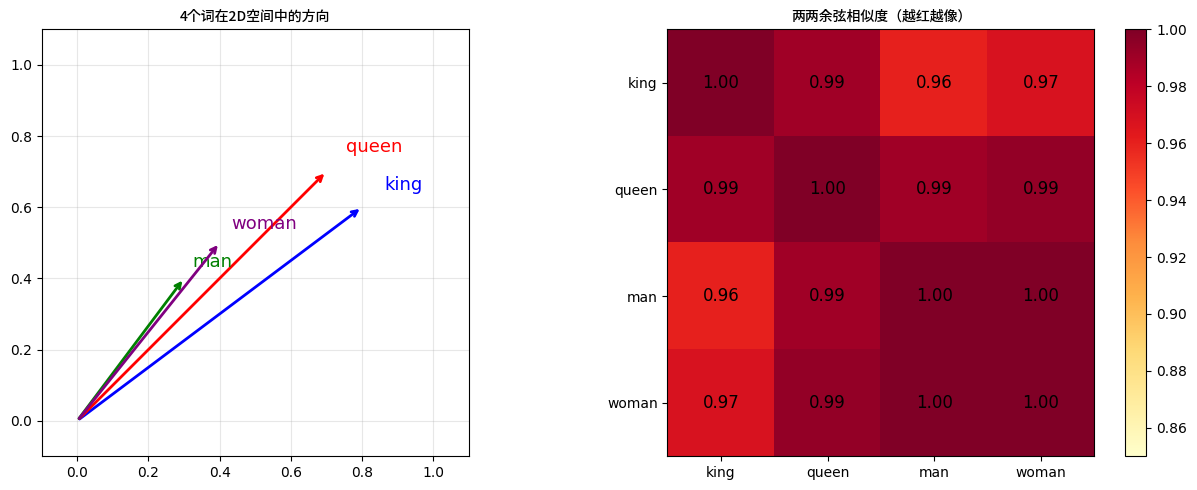

In [14]:
words_2d = {
    'king':  np.array([0.8, 0.6]),
    'queen': np.array([0.7, 0.7]),
    'man':   np.array([0.3, 0.4]),
    'woman': np.array([0.4, 0.5]),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：向量方向
ax = axes[0]
colors = ['blue', 'red', 'green', 'purple']
for (word, vec), color in zip(words_2d.items(), colors):
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', lw=2, color=color))
    ax.text(vec[0]*1.08, vec[1]*1.08, word, fontsize=13, color=color)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('4个词在2D空间中的方向', fontsize=14, fontproperties=zh_font)

# 右图：相似度矩阵
ax = axes[1]
words = list(words_2d.keys())
n = len(words)
sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim[i, j] = cosine_sim(words_2d[words[i]], words_2d[words[j]])

im = ax.imshow(sim, cmap='YlOrRd', vmin=0.85, vmax=1.0)
ax.set_xticks(range(n)); ax.set_xticklabels(words)
ax.set_yticks(range(n)); ax.set_yticklabels(words)
ax.set_title('两两余弦相似度（越红越像）', fontsize=14, fontproperties=zh_font)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
# 七、本节总结

| 概念 | 一句话理解 | AI 用途 |
|-----|----------|--------|
| **向量** | 一串有顺序的数字 | 表示词/图/用户 |
| **维度** | 数字的个数 | GPT-4 用 12288 维 |
| **加法** | 对应位置相加 | 残差连接、参数更新 |
| **标量乘** | 每个元素×同一个数 | 学习率缩放 |
| **点积** | 对应相乘再求和（结果是数字） | **注意力打分** |
| **范数** | 各分量平方和开根号 | 归一化 |
| **余弦相似度** | 点积 / (两个长度的乘积) | **语义搜索、RAG** |

---
# 八、练习

**自己动手做做看，做完再看下面的答案 cell。**

## 题1：猫和狗谁更像？

下面给了 cat 和 dog 的向量，算它们的余弦相似度，跟 king-queen 比较。

In [15]:
cat = np.array([0.5, 0.9, 0.1, 0.7])
dog = np.array([0.4, 0.85, 0.15, 0.65])

# TODO: 用 cosine_sim 算两个相似度，比较
# sim_cd = ?
# sim_kq = ?

## 题2：学习率的影响

把 `lr` 改成 `0.001`、`0.1`、`1.0`、`10.0`，观察参数变化幅度。

想想：学习率太大会怎样？太小呢？

In [16]:
old_params = np.array([10.0, 20.0, 30.0])
gradient   = np.array([5.0, -3.0, 2.0])

for lr in [0.001, 0.1, 1.0, 10.0]:
    # TODO: 算新参数
    new_params = old_params  # ← 改这里
    print(f'lr={lr:>6}: {new_params}, 变化={new_params - old_params}')

lr= 0.001: [10. 20. 30.], 变化=[0. 0. 0.]
lr=   0.1: [10. 20. 30.], 变化=[0. 0. 0.]
lr=   1.0: [10. 20. 30.], 变化=[0. 0. 0.]
lr=  10.0: [10. 20. 30.], 变化=[0. 0. 0.]


## 题3：心算 + 验证

对 `A = [3, 4, 0]` 和 `B = [0, 0, 5]`：

1. 心算：它们的点积是多少？
2. 它们应该是垂直、平行、还是别的？
3. 用代码验证你的答案

**提示**：A 只在 xy 平面里，B 沿 z 轴，一个在平面一个垂直平面 → ?

In [17]:
A = np.array([3, 4, 0])
B = np.array([0, 0, 5])

# TODO: 算点积和余弦相似度

---
## 答案（卡住了再看）

下面的 cell 默认折叠，自己想想再展开。

In [18]:
# === 题1 ===
print(f'cat-dog:    {cosine_sim(cat, dog):.4f}')
print(f'king-queen: {cosine_sim(king, queen):.4f}')
# 两个都接近 1，cat-dog 稍微更像

# === 题2 ===
print()
for lr in [0.001, 0.1, 1.0, 10.0]:
    new = old_params - lr * gradient
    print(f'lr={lr:>6}: {new}')
# lr 太大 → 跳过最优解；lr 太小 → 训练慢

# === 题3 ===
print()
print(f'A·B = {A @ B}')             # 0
print(f'cos = {cosine_sim(A, B)}')  # 0
# A 在 xy 平面，B 在 z 轴 → 垂直 → 点积为 0
# 「垂直 ⇔ 点积为 0」是线代最有用的事实之一

cat-dog:    0.9972
king-queen: 0.9794

lr= 0.001: [ 9.995 20.003 29.998]
lr=   0.1: [ 9.5 20.3 29.8]
lr=   1.0: [ 5. 23. 28.]
lr=  10.0: [-40.  50.  10.]

A·B = 0
cos = 0.0


---
🎉 **第 01 课完成！**

做完后告诉我感觉如何，我继续把第 02 课（矩阵 + 神经网络层）也改成 notebook。